In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install --upgrade kaggle -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 14.0 MB/s eta 0:00:00


In [ ]:
!kaggle auth login


Go to the following link in your browser, and complete the sign-in prompts at Kaggle:

  https://www.kaggle.com/api/v1/oauth2/authorize?response_type=code&client_id=kagglesdk&redirect_uri=https%3A%2F%2Fwww.kaggle.com%2Faccount%2Fapi%2Foauth%2Ftoken&scope=resources.admin%3A%2A&state=b4f6b9a6-cbfb-49a1-a815-3b7a24c7eb2a&code_challenge=UOCSIEmxrtfb1LrXymMIz1FxvtHbOCvrOXTY7bvWZxs%3D&code_challenge_method=S256&response_mode=query

Once finished, enter the verification code provided in your browser: CfDJ8G82xNY93phHtA6xMwIf8xMTd8cT3DkYGTco6qOQd47LBs615qYTEoLps5gLQ7D-ksMM3d2HD-l3L-Q5GmZuPh_xeDnkXMpDVvFMoUQoz82e78xYeRwS9Gt4D_FISJRDr7yZ-dX3u7cvHj-BdCIZCFsnxz5j5B_3S0B39bXD1nsxpTgrGsmOGjRmElSb-voyCfaod7isUKh-xQyPxcsyB8CYL6TePOgMDbc4IWDtQoHarjr7BMDzW26rOe_b-xejFb9UoBvCFkPIHQ2wDEycZfM31Qy36Ge6774JesyMHil7af9BU9ynX6bc6EfCFwNNH5_NO0rWbTFw-CN-9P0QuUCr_JO4

You are now logged in as [aleksiochigava]



In [ ]:
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge -p /content/drive/MyDrive/ml_assn_04/

100% 285M/285M [00:03<00:00, 89.6MB/s]



In [ ]:
!unzip -o /content/drive/MyDrive/ml_assn_04/challenges-in-representation-learning-facial-expression-recognition-challenge.zip -d /content/drive/MyDrive/ml_assn_04/

Archive:  /content/drive/MyDrive/ml_assn_04/challenges-in-representation-learning-facial-expression-recognition-challenge.zip
  inflating: /content/drive/MyDrive/ml_assn_04/example_submission.csv  
  inflating: /content/drive/MyDrive/ml_assn_04/fer2013.tar.gz  
  inflating: /content/drive/MyDrive/ml_assn_04/icml_face_data.csv  
  inflating: /content/drive/MyDrive/ml_assn_04/test.csv  
  inflating: /content/drive/MyDrive/ml_assn_04/train.csv  


In [ ]:
import pandas as pd

train_df = pd.read_csv('/content/drive/MyDrive/ml_assn_04/train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/ml_assn_04/test.csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nColumns:", train_df.columns.tolist())
print("\nEmotion distribution:")
print(train_df['emotion'].value_counts())
print("\nSample row:")
print(train_df.head(1))

Train shape: (28709, 2)
Test shape: (7178, 1)

Columns: ['emotion', 'pixels']

Emotion distribution:
emotion
3    7215
6    4965
4    4830
2    4097
0    3995
5    3171
1     436
Name: count, dtype: int64

Sample row:
   emotion                                             pixels
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...


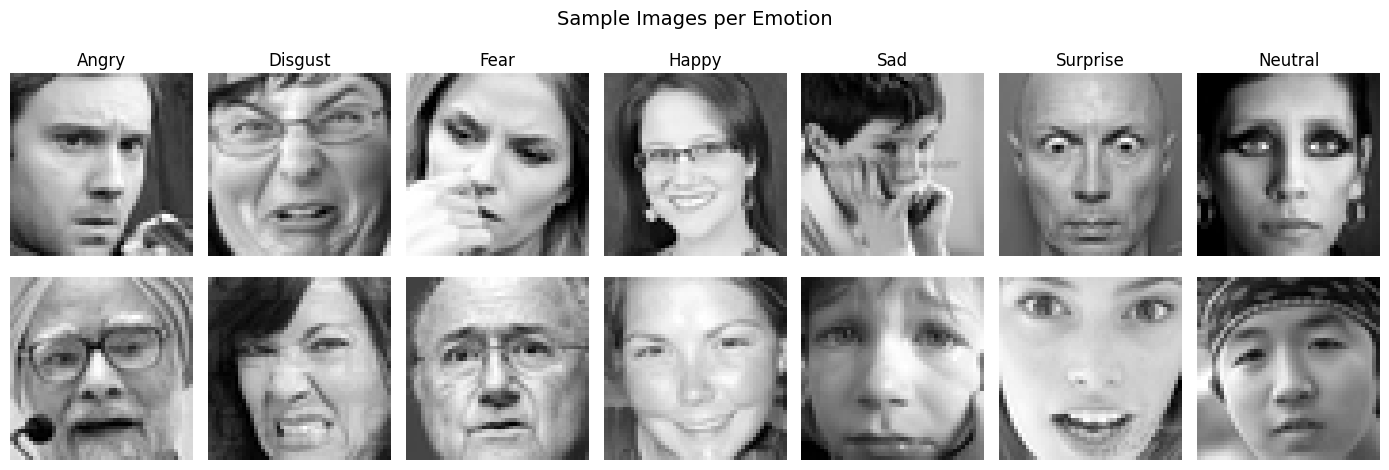

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

fig, axes = plt.subplots(2, 7, figsize=(14, 5))

for emotion_idx in range(7):
    sample = train_df[train_df['emotion'] == emotion_idx].iloc[0]
    pixels = np.array(sample['pixels'].split(), dtype=np.uint8).reshape(48, 48)

    axes[0][emotion_idx].imshow(pixels, cmap='gray')
    axes[0][emotion_idx].set_title(emotion_labels[emotion_idx])
    axes[0][emotion_idx].axis('off')

    sample2 = train_df[train_df['emotion'] == emotion_idx].iloc[1]
    pixels2 = np.array(sample2['pixels'].split(), dtype=np.uint8).reshape(48, 48)
    axes[1][emotion_idx].imshow(pixels2, cmap='gray')
    axes[1][emotion_idx].axis('off')

plt.suptitle('Sample Images per Emotion', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# (0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral)

In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['emotion']
)

print("Train samples:", len(train_df))
print("Val samples:", len(val_df))

Train samples: 18373
Val samples: 4594


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.labels = dataframe['emotion'].values
        self.pixels = dataframe['pixels'].values
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        pixels = np.array(self.pixels[idx].split(), dtype=np.float32)
        image = pixels.reshape(48, 48)

        image = image / 255
        image = torch.tensor(image).unsqueeze(0)

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

In [ ]:
train_dataset = FERDataset(train_df)
val_dataset = FERDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 359
Val batches: 90


In [ ]:
import torch.nn as nn

class TinyCNN(nn.Module):
    def __init__(self):
        super(TinyCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(9216, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 7)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


model = TinyCNN()

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(model)
print("\nDevice:", device)

TinyCNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=9216, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)

Device: cuda


In [ ]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ochiga (ml_assn_04) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
import torch.optim as optim

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        max_scores, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    avg_loss = train_loss / len(train_loader)
    accuracy = 100 * train_correct / train_total
    return avg_loss, accuracy


def validate(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            max_scores, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    avg_loss = val_loss / len(val_loader)
    accuracy = 100 * val_correct / val_total
    return avg_loss, accuracy

In [ ]:
def train_model(model, train_loader, val_loader, epochs, learning_rate, device, run_name, architecture_name, optimizer_name="Adam", optimizer=None, batch_size=64, extra_config=None):
    config = {
        "architecture": architecture_name,
        "epochs": epochs,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "optimizer": optimizer_name,
    }
    if extra_config:
        config.update(extra_config)

    wandb.init(
        project="ml_assn_04",
        group=architecture_name,
        name=run_name,
        config=config
    )

    criterion = nn.CrossEntropyLoss()

    if optimizer is None:
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    wandb.finish()

In [ ]:
model = TinyCNN().to(device)

train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=20,
    learning_rate=0.001,
    device=device,
    run_name="exp01-tiny-cnn",
    architecture_name="TinyCNN"
)

wandb: Currently logged in as: ochiga (ml_assn_04) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/20 | Train Loss: 1.7521 | Train Acc: 28.06% | Val Loss: 1.6153 | Val Acc: 36.64%
Epoch 2/20 | Train Loss: 1.5913 | Train Acc: 37.60% | Val Loss: 1.4888 | Val Acc: 42.08%
Epoch 3/20 | Train Loss: 1.5019 | Train Acc: 41.68% | Val Loss: 1.4377 | Val Acc: 45.16%
Epoch 4/20 | Train Loss: 1.4394 | Train Acc: 44.86% | Val Loss: 1.3986 | Val Acc: 45.94%
Epoch 5/20 | Train Loss: 1.3882 | Train Acc: 46.52% | Val Loss: 1.3711 | Val Acc: 46.73%
Epoch 6/20 | Train Loss: 1.3487 | Train Acc: 48.06% | Val Loss: 1.3288 | Val Acc: 48.68%
Epoch 7/20 | Train Loss: 1.3113 | Train Acc: 49.88% | Val Loss: 1.3165 | Val Acc: 49.72%
Epoch 8/20 | Train Loss: 1.2691 | Train Acc: 51.30% | Val Loss: 1.2906 | Val Acc: 50.84%
Epoch 9/20 | Train Loss: 1.2402 | Train Acc: 52.62% | Val Loss: 1.2863 | Val Acc: 50.89%
Epoch 10/20 | Train Loss: 1.2040 | Train Acc: 53.85% | Val Loss: 1.2699 | Val Acc: 51.22%
Epoch 11/20 | Train Loss: 1.1728 | Train Acc: 54.84% | Val Loss: 1.2795 | Val Acc: 51.69%
Epoch 12/20 | Train

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▃▄▄▄▅▅▅▆▆▆▆▇▇▇▇▇███
train_loss,█▇▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▁▁▁
val_acc,▁▃▅▅▅▆▇▇▇▇▇█████████
val_loss,█▅▄▄▃▂▂▁▁▁▁▁▁▁▁▂▂▃▃▄
epoch,20
train_acc,65.35899
train_loss,0.88746
val_acc,52.5775
val_loss,1.40764


In [ ]:
test_model = TinyCNN().to(device)
optimizer = torch.optim.Adam(test_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [ ]:
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

outputs = test_model(images)
print("FORWARD CHECK")
print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Expected initial loss:", -torch.log(torch.tensor(1/7)).item())
loss = criterion(outputs, labels)
print("Actual initial loss:", loss.item())

FORWARD CHECK
Input shape: torch.Size([64, 1, 48, 48])
Output shape: torch.Size([64, 7])
Expected initial loss: 1.945910096168518
Actual initial loss: 1.9484078884124756


In [ ]:
loss.backward()
print("BACKWARD CHECK")

for name, param in test_model.named_parameters():
    if param.grad is not None:
        print(f"{name}: grad_mean={param.grad.abs().mean().item():.6f}")
    else:
        print(f"{name}: No gradient")

BACKWARD CHECK
conv_layers.0.weight: grad_mean=0.000758
conv_layers.0.bias: grad_mean=0.001660
conv_layers.3.weight: grad_mean=0.000335
conv_layers.3.bias: grad_mean=0.003195
fc_layers.1.weight: grad_mean=0.000301
fc_layers.1.bias: grad_mean=0.004732
fc_layers.4.weight: grad_mean=0.001490
fc_layers.4.bias: grad_mean=0.052706


In [ ]:
before = test_model.fc_layers[1].weight.clone()
optimizer.step()
after = test_model.fc_layers[1].weight

print("OPTIMIZER CHECK")
print("Weights changed:", not torch.equal(before, after))

OPTIMIZER CHECK
Weights changed: True


In [ ]:
small_images, small_labels = next(iter(train_loader))
small_images, small_labels = small_images.to(device), small_labels.to(device)

from torch.utils.data import TensorDataset

small_dataset = TensorDataset(small_images, small_labels)
small_loader = DataLoader(small_dataset, batch_size=64, shuffle=False)

small_model = TinyCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(small_model.parameters(), lr=0.001)

for epoch in range(50):
    small_model.train()
    outputs = small_model(small_images)
    loss = criterion(outputs, small_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    max_scores, predicted = outputs.max(1)
    correct = predicted.eq(small_labels).sum().item()
    acc = 100 * correct / len(small_labels)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 | Loss: {loss.item():.4f} | Acc: {acc:.2f}%")

Epoch 10/50 | Loss: 1.6409 | Acc: 45.31%
Epoch 20/50 | Loss: 1.2165 | Acc: 51.56%
Epoch 30/50 | Loss: 0.8266 | Acc: 73.44%
Epoch 40/50 | Loss: 0.4938 | Acc: 87.50%
Epoch 50/50 | Loss: 0.2940 | Acc: 95.31%


In [ ]:
class MediumCNN(nn.Module):
    def __init__(self, dropout1=0.5, dropout2=0.3):
        super(MediumCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(4608, 256),
            nn.ReLU(),
            nn.Dropout(dropout1),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout2),
            nn.Linear(64, 7)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [ ]:
train_model(
    model=medium_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=20,
    learning_rate=0.001,
    device=device,
    run_name="exp02-medium-cnn-lr0.001",
    architecture_name="MediumCNN"
)

Epoch 1/20 | Train Loss: 1.7421 | Train Acc: 28.47% | Val Loss: 1.5515 | Val Acc: 39.55%
Epoch 2/20 | Train Loss: 1.5473 | Train Acc: 38.86% | Val Loss: 1.5511 | Val Acc: 42.08%
Epoch 3/20 | Train Loss: 1.4533 | Train Acc: 43.24% | Val Loss: 1.4087 | Val Acc: 45.11%
Epoch 4/20 | Train Loss: 1.3930 | Train Acc: 45.71% | Val Loss: 1.3782 | Val Acc: 47.54%
Epoch 5/20 | Train Loss: 1.3451 | Train Acc: 47.48% | Val Loss: 1.3217 | Val Acc: 50.70%
Epoch 6/20 | Train Loss: 1.3032 | Train Acc: 49.17% | Val Loss: 1.3374 | Val Acc: 49.62%
Epoch 7/20 | Train Loss: 1.2662 | Train Acc: 50.88% | Val Loss: 1.2571 | Val Acc: 51.08%
Epoch 8/20 | Train Loss: 1.2312 | Train Acc: 52.04% | Val Loss: 1.2180 | Val Acc: 53.88%
Epoch 9/20 | Train Loss: 1.1898 | Train Acc: 53.72% | Val Loss: 1.2139 | Val Acc: 54.23%
Epoch 10/20 | Train Loss: 1.1616 | Train Acc: 54.53% | Val Loss: 1.2223 | Val Acc: 53.41%
Epoch 11/20 | Train Loss: 1.1264 | Train Acc: 56.53% | Val Loss: 1.1982 | Val Acc: 54.67%
Epoch 12/20 | Train

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▃▄▄▅▅▅▅▆▆▆▆▇▇▇▇████
train_loss,█▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▁▁▁
val_acc,▁▂▃▄▆▅▆▇▇▇▇█▇██▇████
val_loss,██▅▅▃▄▂▁▁▂▁▁▂▁▁▂▁▂▃▂
epoch,20
train_acc,66.28206
train_loss,0.85145
val_acc,55.45106
val_loss,1.25194


In [ ]:
for lr in [0.01, 0.0001, 0.1]:
    model = MediumCNN().to(device)
    train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=20,
        learning_rate=lr,
        device=device,
        run_name=f"medium-cnn-lr{lr}",
        architecture_name="MediumCNN"
    )

Epoch 1/20 | Train Loss: 1.9123 | Train Acc: 24.33% | Val Loss: 1.8112 | Val Acc: 25.13%
Epoch 2/20 | Train Loss: 1.8127 | Train Acc: 25.15% | Val Loss: 1.8106 | Val Acc: 25.13%
Epoch 3/20 | Train Loss: 1.8124 | Train Acc: 25.12% | Val Loss: 1.8097 | Val Acc: 25.13%
Epoch 4/20 | Train Loss: 1.8129 | Train Acc: 25.14% | Val Loss: 1.8100 | Val Acc: 25.13%
Epoch 5/20 | Train Loss: 1.8105 | Train Acc: 25.13% | Val Loss: 1.8097 | Val Acc: 25.13%
Epoch 6/20 | Train Loss: 1.8107 | Train Acc: 25.13% | Val Loss: 1.8102 | Val Acc: 25.13%
Epoch 7/20 | Train Loss: 1.8103 | Train Acc: 25.13% | Val Loss: 1.8101 | Val Acc: 25.13%
Epoch 8/20 | Train Loss: 1.8103 | Train Acc: 25.13% | Val Loss: 1.8100 | Val Acc: 25.13%
Epoch 9/20 | Train Loss: 1.8121 | Train Acc: 25.12% | Val Loss: 1.8098 | Val Acc: 25.13%
Epoch 10/20 | Train Loss: 1.8107 | Train Acc: 25.13% | Val Loss: 1.8098 | Val Acc: 25.13%
Epoch 11/20 | Train Loss: 1.8105 | Train Acc: 25.13% | Val Loss: 1.8099 | Val Acc: 25.13%
Epoch 12/20 | Train

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁███████████████████
train_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▅▁▂▁▃▃▂▁▂▂▂▂▆▂▂▁▃▅▆
epoch,20
train_acc,25.13171
train_loss,1.81026
val_acc,25.13062
val_loss,1.81076


Epoch 1/20 | Train Loss: 1.7453 | Train Acc: 28.95% | Val Loss: 1.5741 | Val Acc: 38.96%
Epoch 2/20 | Train Loss: 1.5594 | Train Acc: 39.28% | Val Loss: 1.4404 | Val Acc: 44.98%
Epoch 3/20 | Train Loss: 1.4689 | Train Acc: 43.61% | Val Loss: 1.3825 | Val Acc: 46.59%
Epoch 4/20 | Train Loss: 1.3999 | Train Acc: 46.69% | Val Loss: 1.3628 | Val Acc: 49.01%
Epoch 5/20 | Train Loss: 1.3589 | Train Acc: 48.58% | Val Loss: 1.2986 | Val Acc: 51.52%
Epoch 6/20 | Train Loss: 1.3090 | Train Acc: 50.71% | Val Loss: 1.2962 | Val Acc: 50.75%
Epoch 7/20 | Train Loss: 1.2672 | Train Acc: 52.04% | Val Loss: 1.2507 | Val Acc: 52.49%
Epoch 8/20 | Train Loss: 1.2257 | Train Acc: 53.88% | Val Loss: 1.2476 | Val Acc: 52.54%
Epoch 9/20 | Train Loss: 1.1912 | Train Acc: 55.49% | Val Loss: 1.2935 | Val Acc: 51.69%
Epoch 10/20 | Train Loss: 1.1542 | Train Acc: 57.11% | Val Loss: 1.2077 | Val Acc: 53.78%
Epoch 11/20 | Train Loss: 1.1087 | Train Acc: 58.91% | Val Loss: 1.1752 | Val Acc: 55.97%
Epoch 12/20 | Train

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▃▃▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇██
train_loss,█▇▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▁▁
val_acc,▁▃▄▅▆▆▆▆▆▇█▇▇▇▇█▇██▇
val_loss,█▆▅▄▃▃▂▂▃▂▁▁▁▁▂▁▁▂▁▃
epoch,20
train_acc,71.63757
train_loss,0.7718
val_acc,54.23197
val_loss,1.28836


Epoch 1/20 | Train Loss: 12.2307 | Train Acc: 24.80% | Val Loss: 1.8167 | Val Acc: 25.13%
Epoch 2/20 | Train Loss: 1.8195 | Train Acc: 24.84% | Val Loss: 1.8162 | Val Acc: 25.13%
Epoch 3/20 | Train Loss: 1.8170 | Train Acc: 24.91% | Val Loss: 1.8159 | Val Acc: 25.13%
Epoch 4/20 | Train Loss: 1.8173 | Train Acc: 24.90% | Val Loss: 1.8161 | Val Acc: 25.13%
Epoch 5/20 | Train Loss: 1.8157 | Train Acc: 24.97% | Val Loss: 1.8230 | Val Acc: 25.13%
Epoch 6/20 | Train Loss: 1.8180 | Train Acc: 24.88% | Val Loss: 1.8126 | Val Acc: 25.13%
Epoch 7/20 | Train Loss: 1.8167 | Train Acc: 24.74% | Val Loss: 1.8119 | Val Acc: 25.13%
Epoch 8/20 | Train Loss: 1.8156 | Train Acc: 25.04% | Val Loss: 1.8134 | Val Acc: 25.13%
Epoch 9/20 | Train Loss: 1.8163 | Train Acc: 25.13% | Val Loss: 1.8129 | Val Acc: 25.13%
Epoch 10/20 | Train Loss: 1.8168 | Train Acc: 25.05% | Val Loss: 1.8184 | Val Acc: 25.13%
Epoch 11/20 | Train Loss: 1.8166 | Train Acc: 25.13% | Val Loss: 1.8148 | Val Acc: 25.13%
Epoch 12/20 | Trai

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▂▃▄▄▅▃▁▆█▇█▁▅▄▇██▄▅▅
train_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,▄▄▄▄█▂▁▂▂▅▃▃▇▄▂█▄▆▁▄
epoch,20
train_acc,24.98367
train_loss,1.816
val_acc,25.13062
val_loss,1.81614


In [ ]:
import torch.optim as optim

optimizers_config = {
    "SGD":      lambda p: optim.SGD(p, lr=0.001),
    "SGD-Momentum": lambda p: optim.SGD(p, lr=0.001, momentum=0.9),
    "NAG":      lambda p: optim.SGD(p, lr=0.001, momentum=0.9, nesterov=True),
    "Adagrad":  lambda p: optim.Adagrad(p, lr=0.001),
    "Adadelta": lambda p: optim.Adadelta(p, lr=0.001),
    "RMSprop":  lambda p: optim.RMSprop(p, lr=0.001),
    #"Adam":     lambda p: optim.Adam(p, lr=0.001),
}

for optimizer_name, opt_fn in optimizers_config.items():
    model = MediumCNN().to(device)
    optimizer = opt_fn(model.parameters())

    train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=20,
        learning_rate=0.001,
        device=device,
        run_name=f"medium-cnn-opt-{optimizer_name.lower()}",
        architecture_name="MediumCNN",
        optimizer_name=optimizer_name,
        optimizer=optimizer
    )

Epoch 1/20 | Train Loss: 1.8618 | Train Acc: 23.51% | Val Loss: 1.8077 | Val Acc: 25.13%
Epoch 2/20 | Train Loss: 1.8152 | Train Acc: 25.01% | Val Loss: 1.7812 | Val Acc: 25.32%
Epoch 3/20 | Train Loss: 1.7918 | Train Acc: 25.87% | Val Loss: 1.7615 | Val Acc: 26.98%
Epoch 4/20 | Train Loss: 1.7750 | Train Acc: 26.73% | Val Loss: 1.7419 | Val Acc: 29.43%
Epoch 5/20 | Train Loss: 1.7586 | Train Acc: 28.12% | Val Loss: 1.7245 | Val Acc: 30.37%
Epoch 6/20 | Train Loss: 1.7412 | Train Acc: 29.20% | Val Loss: 1.7061 | Val Acc: 30.70%
Epoch 7/20 | Train Loss: 1.7215 | Train Acc: 30.44% | Val Loss: 1.6831 | Val Acc: 33.11%
Epoch 8/20 | Train Loss: 1.7028 | Train Acc: 31.74% | Val Loss: 1.6605 | Val Acc: 34.00%
Epoch 9/20 | Train Loss: 1.6853 | Train Acc: 32.93% | Val Loss: 1.6399 | Val Acc: 35.98%
Epoch 10/20 | Train Loss: 1.6661 | Train Acc: 33.85% | Val Loss: 1.6160 | Val Acc: 37.53%
Epoch 11/20 | Train Loss: 1.6438 | Train Acc: 35.24% | Val Loss: 1.5911 | Val Acc: 38.47%
Epoch 12/20 | Train

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▂▂▂▃▃▄▄▅▅▅▆▆▆▇▇▇▇██
train_loss,█▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁
val_acc,▁▁▂▃▃▃▄▄▅▆▆▆▇▇▇▇▇███
val_loss,█▇▇▇▆▆▆▅▅▄▄▃▃▃▂▂▂▁▁▁
epoch,20
train_acc,41.96891
train_loss,1.50483
val_acc,44.35737
val_loss,1.4545


Epoch 1/20 | Train Loss: 1.8045 | Train Acc: 24.81% | Val Loss: 1.7189 | Val Acc: 27.81%
Epoch 2/20 | Train Loss: 1.6812 | Train Acc: 33.34% | Val Loss: 1.5714 | Val Acc: 40.35%
Epoch 3/20 | Train Loss: 1.5730 | Train Acc: 38.91% | Val Loss: 1.5029 | Val Acc: 41.80%
Epoch 4/20 | Train Loss: 1.5005 | Train Acc: 42.16% | Val Loss: 1.4452 | Val Acc: 44.20%
Epoch 5/20 | Train Loss: 1.4441 | Train Acc: 44.68% | Val Loss: 1.3754 | Val Acc: 46.87%
Epoch 6/20 | Train Loss: 1.4007 | Train Acc: 46.73% | Val Loss: 1.4707 | Val Acc: 44.22%
Epoch 7/20 | Train Loss: 1.3641 | Train Acc: 47.92% | Val Loss: 1.3346 | Val Acc: 49.27%
Epoch 8/20 | Train Loss: 1.3294 | Train Acc: 49.47% | Val Loss: 1.4304 | Val Acc: 43.94%
Epoch 9/20 | Train Loss: 1.2933 | Train Acc: 51.44% | Val Loss: 1.2611 | Val Acc: 52.09%
Epoch 10/20 | Train Loss: 1.2647 | Train Acc: 52.30% | Val Loss: 1.2700 | Val Acc: 51.27%
Epoch 11/20 | Train Loss: 1.2308 | Train Acc: 53.42% | Val Loss: 1.3703 | Val Acc: 48.96%
Epoch 12/20 | Train

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▃▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇███
train_loss,█▇▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▁▁▁
val_acc,▁▄▄▅▆▅▆▅▇▇▆▇█▇▇████▇
val_loss,█▆▅▄▄▅▃▄▂▂▄▂▁▁▁▁▁▁▁▂
epoch,20
train_acc,63.72622
train_loss,0.97104
val_acc,53.29154
val_loss,1.27119


Epoch 1/20 | Train Loss: 1.7863 | Train Acc: 25.93% | Val Loss: 1.6924 | Val Acc: 30.67%
Epoch 2/20 | Train Loss: 1.6692 | Train Acc: 33.59% | Val Loss: 1.5813 | Val Acc: 39.74%
Epoch 3/20 | Train Loss: 1.5607 | Train Acc: 39.48% | Val Loss: 1.5477 | Val Acc: 38.96%
Epoch 4/20 | Train Loss: 1.4877 | Train Acc: 42.50% | Val Loss: 1.4231 | Val Acc: 46.53%
Epoch 5/20 | Train Loss: 1.4287 | Train Acc: 45.56% | Val Loss: 1.3670 | Val Acc: 48.15%
Epoch 6/20 | Train Loss: 1.3829 | Train Acc: 47.10% | Val Loss: 1.3958 | Val Acc: 46.66%
Epoch 7/20 | Train Loss: 1.3394 | Train Acc: 48.98% | Val Loss: 1.3058 | Val Acc: 50.37%
Epoch 8/20 | Train Loss: 1.3046 | Train Acc: 50.76% | Val Loss: 1.2729 | Val Acc: 50.91%
Epoch 9/20 | Train Loss: 1.2672 | Train Acc: 52.21% | Val Loss: 1.2798 | Val Acc: 51.20%
Epoch 10/20 | Train Loss: 1.2339 | Train Acc: 53.69% | Val Loss: 1.2328 | Val Acc: 53.05%
Epoch 11/20 | Train Loss: 1.2000 | Train Acc: 55.10% | Val Loss: 1.2177 | Val Acc: 53.74%
Epoch 12/20 | Train

...

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▄▄▅▅▆▆▆▆▇▇▇▇▇▇█████
train_loss,█▆▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁
val_acc,▁▃▄▄▅▅▅▆▆▆▇▇▇▇██████
val_loss,█▆▅▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
epoch,20
train_acc,52.45787
train_loss,1.26871
val_acc,52.1247
val_loss,1.26525


Epoch 1/20 | Train Loss: 1.8994 | Train Acc: 21.45% | Val Loss: 1.8526 | Val Acc: 25.17%
Epoch 2/20 | Train Loss: 1.8585 | Train Acc: 23.44% | Val Loss: 1.8227 | Val Acc: 25.13%
Epoch 3/20 | Train Loss: 1.8377 | Train Acc: 24.18% | Val Loss: 1.8071 | Val Acc: 25.15%
Epoch 4/20 | Train Loss: 1.8284 | Train Acc: 23.97% | Val Loss: 1.7923 | Val Acc: 25.15%
Epoch 5/20 | Train Loss: 1.8207 | Train Acc: 24.62% | Val Loss: 1.7841 | Val Acc: 25.48%
Epoch 6/20 | Train Loss: 1.8089 | Train Acc: 25.05% | Val Loss: 1.7733 | Val Acc: 26.31%
Epoch 7/20 | Train Loss: 1.8004 | Train Acc: 25.35% | Val Loss: 1.7631 | Val Acc: 27.12%
Epoch 8/20 | Train Loss: 1.7936 | Train Acc: 26.04% | Val Loss: 1.7558 | Val Acc: 28.34%
Epoch 9/20 | Train Loss: 1.7842 | Train Acc: 26.35% | Val Loss: 1.7474 | Val Acc: 29.17%
Epoch 10/20 | Train Loss: 1.7807 | Train Acc: 27.39% | Val Loss: 1.7409 | Val Acc: 30.02%
Epoch 11/20 | Train Loss: 1.7691 | Train Acc: 27.70% | Val Loss: 1.7312 | Val Acc: 30.08%
Epoch 12/20 | Train

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▂▃▃▃▃▃▄▄▅▅▅▆▆▇▇▇▇██
train_loss,█▇▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁
val_acc,▁▁▁▁▁▂▂▃▄▄▄▅▆▆▆▇▇▇██
val_loss,█▇▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▁▁
epoch,20
train_acc,32.40301
train_loss,1.70287
val_acc,36.03274
val_loss,1.66088


Epoch 1/20 | Train Loss: 1.9416 | Train Acc: 23.45% | Val Loss: 1.7286 | Val Acc: 28.42%
Epoch 2/20 | Train Loss: 1.6780 | Train Acc: 32.19% | Val Loss: 1.6131 | Val Acc: 37.41%
Epoch 3/20 | Train Loss: 1.5513 | Train Acc: 39.22% | Val Loss: 1.5448 | Val Acc: 39.05%
Epoch 4/20 | Train Loss: 1.4682 | Train Acc: 43.21% | Val Loss: 1.4057 | Val Acc: 47.34%
Epoch 5/20 | Train Loss: 1.4218 | Train Acc: 45.30% | Val Loss: 1.3967 | Val Acc: 48.08%
Epoch 6/20 | Train Loss: 1.3787 | Train Acc: 46.59% | Val Loss: 1.3560 | Val Acc: 49.91%
Epoch 7/20 | Train Loss: 1.3475 | Train Acc: 47.84% | Val Loss: 1.3212 | Val Acc: 50.07%
Epoch 8/20 | Train Loss: 1.3193 | Train Acc: 48.85% | Val Loss: 1.3395 | Val Acc: 48.55%
Epoch 9/20 | Train Loss: 1.2933 | Train Acc: 50.06% | Val Loss: 1.3168 | Val Acc: 51.29%
Epoch 10/20 | Train Loss: 1.2512 | Train Acc: 51.84% | Val Loss: 1.2953 | Val Acc: 50.44%
Epoch 11/20 | Train Loss: 1.2263 | Train Acc: 52.90% | Val Loss: 1.2721 | Val Acc: 53.07%
Epoch 12/20 | Train

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▃▄▅▅▅▅▆▆▆▆▇▇▇▇▇████
train_loss,█▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁
val_acc,▁▃▄▆▆▆▆▆▇▇▇█▆▇████▇█
val_loss,█▆▆▄▄▃▃▃▃▂▂▁▃▂▁▂▁▁▂▂
epoch,20
train_acc,61.6798
train_loss,0.98419
val_acc,55.92128
val_loss,1.23915


In [ ]:
batch_sizes = [32, 64, 128]

for batch_size in batch_sizes:
    train_loader_bs = DataLoader(FERDataset(train_df), batch_size=batch_size, shuffle=True)
    val_loader_bs = DataLoader(FERDataset(val_df), batch_size=batch_size, shuffle=False)

    model = MediumCNN().to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, nesterov=True)

    train_model(
        model=model,
        train_loader=train_loader_bs,
        val_loader=val_loader_bs,
        epochs=20,
        learning_rate=0.001,
        device=device,
        run_name=f"medium-cnn-batch_size{batch_size}",
        architecture_name="MediumCNN",
        optimizer_name="NAG",
        optimizer=optimizer,
        batch_size=batch_size
    )

Epoch 1/20 | Train Loss: 1.7501 | Train Acc: 28.67% | Val Loss: 1.5968 | Val Acc: 38.16%
Epoch 2/20 | Train Loss: 1.5713 | Train Acc: 38.63% | Val Loss: 1.4567 | Val Acc: 44.32%
Epoch 3/20 | Train Loss: 1.4751 | Train Acc: 42.78% | Val Loss: 1.3877 | Val Acc: 47.28%
Epoch 4/20 | Train Loss: 1.4067 | Train Acc: 46.11% | Val Loss: 1.3978 | Val Acc: 46.85%
Epoch 5/20 | Train Loss: 1.3540 | Train Acc: 48.63% | Val Loss: 1.2802 | Val Acc: 51.13%
Epoch 6/20 | Train Loss: 1.3053 | Train Acc: 50.19% | Val Loss: 1.2723 | Val Acc: 52.42%
Epoch 7/20 | Train Loss: 1.2648 | Train Acc: 52.09% | Val Loss: 1.2345 | Val Acc: 53.10%
Epoch 8/20 | Train Loss: 1.2249 | Train Acc: 53.20% | Val Loss: 1.2221 | Val Acc: 53.81%
Epoch 9/20 | Train Loss: 1.1975 | Train Acc: 54.94% | Val Loss: 1.1908 | Val Acc: 55.54%
Epoch 10/20 | Train Loss: 1.1548 | Train Acc: 56.21% | Val Loss: 1.2065 | Val Acc: 54.20%
Epoch 11/20 | Train Loss: 1.1306 | Train Acc: 57.47% | Val Loss: 1.1827 | Val Acc: 55.61%
Epoch 12/20 | Train

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▃▃▄▅▅▅▅▆▆▆▆▆▇▇▇▇███
train_loss,█▇▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁
val_acc,▁▃▄▄▆▆▆▇▇▇▇▆▇█▇█████
val_loss,█▆▅▅▃▃▂▂▂▂▁▃▂▁▃▁▂▁▁▂
epoch,20
train_acc,68.42861
train_loss,0.84477
val_acc,57.12295
val_loss,1.19846


Epoch 1/20 | Train Loss: 1.7854 | Train Acc: 26.66% | Val Loss: 1.6820 | Val Acc: 33.47%
Epoch 2/20 | Train Loss: 1.6546 | Train Acc: 34.68% | Val Loss: 1.5631 | Val Acc: 38.26%
Epoch 3/20 | Train Loss: 1.5604 | Train Acc: 39.39% | Val Loss: 1.4601 | Val Acc: 43.40%
Epoch 4/20 | Train Loss: 1.4873 | Train Acc: 42.64% | Val Loss: 1.4330 | Val Acc: 44.90%
Epoch 5/20 | Train Loss: 1.4344 | Train Acc: 45.35% | Val Loss: 1.3844 | Val Acc: 47.13%
Epoch 6/20 | Train Loss: 1.3824 | Train Acc: 47.31% | Val Loss: 1.3336 | Val Acc: 49.15%
Epoch 7/20 | Train Loss: 1.3405 | Train Acc: 49.44% | Val Loss: 1.2973 | Val Acc: 50.77%
Epoch 8/20 | Train Loss: 1.3094 | Train Acc: 50.23% | Val Loss: 1.2696 | Val Acc: 51.53%
Epoch 9/20 | Train Loss: 1.2678 | Train Acc: 51.75% | Val Loss: 1.2672 | Val Acc: 51.69%
Epoch 10/20 | Train Loss: 1.2355 | Train Acc: 52.83% | Val Loss: 1.2428 | Val Acc: 53.69%
Epoch 11/20 | Train Loss: 1.2054 | Train Acc: 54.74% | Val Loss: 1.2470 | Val Acc: 52.73%
Epoch 12/20 | Train

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▂▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇███
train_loss,█▇▆▆▅▅▄▄▄▃▃▃▃▂▂▂▂▁▁▁
val_acc,▁▂▄▅▅▆▆▇▇▇▇▇▆▇██▇███
val_loss,█▆▅▅▄▃▃▂▂▂▂▁▃▁▁▁▂▁▂▁
epoch,20
train_acc,64.90182
train_loss,0.93908
val_acc,56.19993
val_loss,1.20994


Epoch 1/20 | Train Loss: 1.8208 | Train Acc: 24.37% | Val Loss: 1.7390 | Val Acc: 27.45%
Epoch 2/20 | Train Loss: 1.7332 | Train Acc: 29.61% | Val Loss: 1.6602 | Val Acc: 34.71%
Epoch 3/20 | Train Loss: 1.6571 | Train Acc: 34.61% | Val Loss: 1.5797 | Val Acc: 38.68%
Epoch 4/20 | Train Loss: 1.5860 | Train Acc: 38.06% | Val Loss: 1.5083 | Val Acc: 42.74%
Epoch 5/20 | Train Loss: 1.5317 | Train Acc: 40.94% | Val Loss: 1.4580 | Val Acc: 43.54%
Epoch 6/20 | Train Loss: 1.4860 | Train Acc: 42.89% | Val Loss: 1.4222 | Val Acc: 45.14%
Epoch 7/20 | Train Loss: 1.4490 | Train Acc: 44.43% | Val Loss: 1.3895 | Val Acc: 46.83%
Epoch 8/20 | Train Loss: 1.4164 | Train Acc: 46.06% | Val Loss: 1.3680 | Val Acc: 47.89%
Epoch 9/20 | Train Loss: 1.3824 | Train Acc: 47.42% | Val Loss: 1.3414 | Val Acc: 48.24%
Epoch 10/20 | Train Loss: 1.3495 | Train Acc: 48.70% | Val Loss: 1.3156 | Val Acc: 50.12%
Epoch 11/20 | Train Loss: 1.3227 | Train Acc: 50.16% | Val Loss: 1.2954 | Val Acc: 50.82%
Epoch 12/20 | Train

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▂▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇██
train_loss,█▇▆▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁
val_acc,▁▃▄▅▅▆▆▆▆▇▇▇▇▇██████
val_loss,█▇▆▅▄▄▃▃▃▂▂▂▃▂▁▁▁▁▁▁
epoch,20
train_acc,59.31119
train_loss,1.09213
val_acc,54.38871
val_loss,1.21941


In [ ]:
train_loader_bs32 = DataLoader(FERDataset(train_df), batch_size=32, shuffle=True)
val_loader_bs32 = DataLoader(FERDataset(val_df), batch_size=32, shuffle=False)

reg_configs = {
    "no-dropout": dict(dropout1=0.0, dropout2=0.0, weight_decay=0.0),
    "current-dropout": dict(dropout1=0.5, dropout2=0.3, weight_decay=0.0),
    "high-dropout": dict(dropout1=0.6, dropout2=0.4, weight_decay=0.0),
    "weight-decay": dict(dropout1=0.5, dropout2=0.3, weight_decay=1e-4),
}

for reg_name, cfg in reg_configs.items():
    model = MediumCNN(dropout1=cfg["dropout1"], dropout2=cfg["dropout2"]).to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, nesterov=True, weight_decay=cfg["weight_decay"])

    train_model(
        model=model,
        train_loader=train_loader_bs32,
        val_loader=val_loader_bs32,
        epochs=20,
        learning_rate=0.001,
        device=device,
        run_name=f"medium-cnn-reg-{reg_name}",
        architecture_name="MediumCNN",
        optimizer_name="NAG",
        optimizer=optimizer,
        batch_size=32,
        extra_config={"dropout1": cfg["dropout1"], "dropout2": cfg["dropout2"], "weight_decay": cfg["weight_decay"]}
    )

Epoch 1/20 | Train Loss: 1.6482 | Train Acc: 34.67% | Val Loss: 1.5214 | Val Acc: 40.44%
Epoch 2/20 | Train Loss: 1.4117 | Train Acc: 46.33% | Val Loss: 1.3573 | Val Acc: 48.26%
Epoch 3/20 | Train Loss: 1.2895 | Train Acc: 51.17% | Val Loss: 1.5934 | Val Acc: 43.00%
Epoch 4/20 | Train Loss: 1.2017 | Train Acc: 54.69% | Val Loss: 1.2536 | Val Acc: 52.33%
Epoch 5/20 | Train Loss: 1.1215 | Train Acc: 57.95% | Val Loss: 1.2554 | Val Acc: 52.84%
Epoch 6/20 | Train Loss: 1.0493 | Train Acc: 60.66% | Val Loss: 1.2385 | Val Acc: 53.33%
Epoch 7/20 | Train Loss: 0.9714 | Train Acc: 63.78% | Val Loss: 1.3666 | Val Acc: 47.89%
Epoch 8/20 | Train Loss: 0.8973 | Train Acc: 66.88% | Val Loss: 1.2916 | Val Acc: 53.67%
Epoch 9/20 | Train Loss: 0.8215 | Train Acc: 69.70% | Val Loss: 1.2900 | Val Acc: 54.27%
Epoch 10/20 | Train Loss: 0.7455 | Train Acc: 72.62% | Val Loss: 1.4978 | Val Acc: 52.02%
Epoch 11/20 | Train Loss: 0.6658 | Train Acc: 75.83% | Val Loss: 1.6657 | Val Acc: 49.46%
Epoch 12/20 | Train

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▂▃▃▄▄▄▅▅▆▆▆▇▇▇▇▇███
train_loss,█▇▆▆▅▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁
val_acc,▁▅▂▇▇▇▅██▇▅▇▇██▇▇▆██
val_loss,▃▂▃▁▁▁▂▁▁▃▄▃▃▄▄▅▅▆▇█
epoch,20
train_acc,93.39052
train_loss,0.18873
val_acc,53.97074
val_loss,2.24527


Epoch 1/20 | Train Loss: 1.7428 | Train Acc: 28.73% | Val Loss: 1.6028 | Val Acc: 36.62%
Epoch 2/20 | Train Loss: 1.5723 | Train Acc: 38.80% | Val Loss: 1.4683 | Val Acc: 42.91%
Epoch 3/20 | Train Loss: 1.4699 | Train Acc: 43.98% | Val Loss: 1.3993 | Val Acc: 45.61%
Epoch 4/20 | Train Loss: 1.4090 | Train Acc: 46.06% | Val Loss: 1.3266 | Val Acc: 49.91%
Epoch 5/20 | Train Loss: 1.3564 | Train Acc: 48.27% | Val Loss: 1.3097 | Val Acc: 51.65%
Epoch 6/20 | Train Loss: 1.3085 | Train Acc: 50.35% | Val Loss: 1.2597 | Val Acc: 52.09%
Epoch 7/20 | Train Loss: 1.2667 | Train Acc: 52.00% | Val Loss: 1.2373 | Val Acc: 52.06%
Epoch 8/20 | Train Loss: 1.2326 | Train Acc: 53.32% | Val Loss: 1.2447 | Val Acc: 52.11%
Epoch 9/20 | Train Loss: 1.1903 | Train Acc: 55.28% | Val Loss: 1.2343 | Val Acc: 53.38%
Epoch 10/20 | Train Loss: 1.1644 | Train Acc: 56.34% | Val Loss: 1.2400 | Val Acc: 53.19%
Epoch 11/20 | Train Loss: 1.1255 | Train Acc: 57.75% | Val Loss: 1.1873 | Val Acc: 54.62%
Epoch 12/20 | Train

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▃▄▄▄▅▅▅▆▆▆▆▇▇▇▇▇███
train_loss,█▇▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▁▁▁
val_acc,▁▃▄▅▆▆▆▆▇▇▇▇██▇██▇██
val_loss,█▆▅▄▃▃▂▂▂▂▂▃▁▁▁▁▂▂▁▂
epoch,20
train_acc,68.15431
train_loss,0.85125
val_acc,57.33194
val_loss,1.1884


Epoch 1/20 | Train Loss: 1.7935 | Train Acc: 25.71% | Val Loss: 1.6721 | Val Acc: 31.07%
Epoch 2/20 | Train Loss: 1.6459 | Train Acc: 34.68% | Val Loss: 1.5243 | Val Acc: 42.23%
Epoch 3/20 | Train Loss: 1.5402 | Train Acc: 40.11% | Val Loss: 1.4500 | Val Acc: 43.80%
Epoch 4/20 | Train Loss: 1.4817 | Train Acc: 42.57% | Val Loss: 1.3822 | Val Acc: 47.07%
Epoch 5/20 | Train Loss: 1.4313 | Train Acc: 45.00% | Val Loss: 1.3569 | Val Acc: 48.15%
Epoch 6/20 | Train Loss: 1.3877 | Train Acc: 46.55% | Val Loss: 1.3311 | Val Acc: 49.25%
Epoch 7/20 | Train Loss: 1.3516 | Train Acc: 47.92% | Val Loss: 1.2960 | Val Acc: 49.95%
Epoch 8/20 | Train Loss: 1.3133 | Train Acc: 50.22% | Val Loss: 1.2914 | Val Acc: 49.70%
Epoch 9/20 | Train Loss: 1.2870 | Train Acc: 50.96% | Val Loss: 1.2438 | Val Acc: 52.54%
Epoch 10/20 | Train Loss: 1.2550 | Train Acc: 52.15% | Val Loss: 1.2383 | Val Acc: 52.58%
Epoch 11/20 | Train Loss: 1.2284 | Train Acc: 53.47% | Val Loss: 1.2055 | Val Acc: 54.67%
Epoch 12/20 | Train

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇████
train_loss,█▇▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁
val_acc,▁▄▄▅▆▆▆▆▇▇▇▇▇█▇████▇
val_loss,█▆▅▄▄▃▃▃▂▂▂▂▂▁▂▁▁▂▁▂
epoch,20
train_acc,61.49258
train_loss,1.01453
val_acc,55.12017
val_loss,1.21655


Epoch 1/20 | Train Loss: 1.7515 | Train Acc: 28.09% | Val Loss: 1.5972 | Val Acc: 36.17%
Epoch 2/20 | Train Loss: 1.5752 | Train Acc: 38.38% | Val Loss: 1.4476 | Val Acc: 43.87%
Epoch 3/20 | Train Loss: 1.4705 | Train Acc: 43.56% | Val Loss: 1.3912 | Val Acc: 47.23%
Epoch 4/20 | Train Loss: 1.4048 | Train Acc: 46.04% | Val Loss: 1.3673 | Val Acc: 47.79%
Epoch 5/20 | Train Loss: 1.3559 | Train Acc: 48.33% | Val Loss: 1.2992 | Val Acc: 50.31%
Epoch 6/20 | Train Loss: 1.3079 | Train Acc: 50.49% | Val Loss: 1.2734 | Val Acc: 51.57%
Epoch 7/20 | Train Loss: 1.2728 | Train Acc: 52.06% | Val Loss: 1.2444 | Val Acc: 53.31%
Epoch 8/20 | Train Loss: 1.2285 | Train Acc: 53.72% | Val Loss: 1.2264 | Val Acc: 53.20%
Epoch 9/20 | Train Loss: 1.1997 | Train Acc: 54.69% | Val Loss: 1.2217 | Val Acc: 53.88%
Epoch 10/20 | Train Loss: 1.1618 | Train Acc: 55.79% | Val Loss: 1.1988 | Val Acc: 54.56%
Epoch 11/20 | Train Loss: 1.1242 | Train Acc: 57.50% | Val Loss: 1.1898 | Val Acc: 55.54%
Epoch 12/20 | Train

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▃▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇███
train_loss,█▇▆▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▁▁
val_acc,▁▄▅▅▆▆▇▇▇▇▇▆▇█▇█████
val_loss,█▆▅▄▃▃▃▂▂▂▂▃▁▁▂▁▁▁▂▂
epoch,20
train_acc,68.6289
train_loss,0.83717
val_acc,56.65273
val_loss,1.22103


In [ ]:
class DeepCNN(nn.Module):
    def __init__(self, dropout1=0.5, dropout2=0.3):
        super(DeepCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(dropout1),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout2),
            nn.Linear(64, 7)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [ ]:
test_model = DeepCNN().to(device)
optimizer = torch.optim.SGD(test_model.parameters(), lr=0.001, momentum=0.9, nesterov=True)
criterion = nn.CrossEntropyLoss()

In [ ]:
images, labels = next(iter(train_loader_bs32))
images, labels = images.to(device), labels.to(device)

outputs = test_model(images)
print("FORWARD CHECK")
print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Expected initial loss:", -torch.log(torch.tensor(1/7)).item())
loss = criterion(outputs, labels)
print("Actual initial loss:", loss.item())

FORWARD CHECK
Input shape: torch.Size([32, 1, 48, 48])
Output shape: torch.Size([32, 7])
Expected initial loss: 1.945910096168518
Actual initial loss: 1.9571468830108643


In [ ]:
loss.backward()
print("BACKWARD CHECK")

for name, param in test_model.named_parameters():
    if param.grad is not None:
        print(f"{name}: grad_mean={param.grad.abs().mean().item():.6f}")
    else:
        print(f"{name}: No gradient")

BACKWARD CHECK
conv_layers.0.weight: grad_mean=0.017387
conv_layers.0.bias: grad_mean=0.000000
conv_layers.1.weight: grad_mean=0.007836
conv_layers.1.bias: grad_mean=0.007677
conv_layers.3.weight: grad_mean=0.013699
conv_layers.3.bias: grad_mean=0.000000
conv_layers.4.weight: grad_mean=0.008107
conv_layers.4.bias: grad_mean=0.005524
conv_layers.7.weight: grad_mean=0.007918
conv_layers.7.bias: grad_mean=0.000000
conv_layers.8.weight: grad_mean=0.003938
conv_layers.8.bias: grad_mean=0.003614
conv_layers.10.weight: grad_mean=0.006784
conv_layers.10.bias: grad_mean=0.000000
conv_layers.11.weight: grad_mean=0.003932
conv_layers.11.bias: grad_mean=0.002086
conv_layers.14.weight: grad_mean=0.004173
conv_layers.14.bias: grad_mean=0.000000
conv_layers.15.weight: grad_mean=0.001801
conv_layers.15.bias: grad_mean=0.001659
conv_layers.17.weight: grad_mean=0.003546
conv_layers.17.bias: grad_mean=0.000000
conv_layers.18.weight: grad_mean=0.002070
conv_layers.18.bias: grad_mean=0.001022
conv_layers.2

In [ ]:
before = test_model.fc_layers[1].weight.clone()
optimizer.step()
after = test_model.fc_layers[1].weight

print("OPTIMIZER CHECK")
print("Weights changed:", not torch.equal(before, after))

OPTIMIZER CHECK
Weights changed: True


In [ ]:
small_images, small_labels = next(iter(train_loader_bs32))
small_images, small_labels = small_images.to(device), small_labels.to(device)

small_model = DeepCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(small_model.parameters(), lr=0.001, momentum=0.9, nesterov=True)

for epoch in range(50):
    small_model.train()
    outputs = small_model(small_images)
    loss = criterion(outputs, small_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    max_scores, predicted = outputs.max(1)
    correct = predicted.eq(small_labels).sum().item()
    acc = 100 * correct / len(small_labels)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 | Loss: {loss.item():.4f} | Acc: {acc:.2f}%")

Epoch 10/50 | Loss: 1.7387 | Acc: 46.88%
Epoch 20/50 | Loss: 1.4784 | Acc: 56.25%
Epoch 30/50 | Loss: 1.2788 | Acc: 56.25%
Epoch 40/50 | Loss: 1.0416 | Acc: 68.75%
Epoch 50/50 | Loss: 0.7657 | Acc: 87.50%


In [ ]:
deep_model = DeepCNN(dropout1=0.5, dropout2=0.3).to(device)
optimizer = optim.SGD(deep_model.parameters(), lr=0.001, momentum=0.9, nesterov=True)

train_model(
    model=deep_model,
    train_loader=train_loader_bs32,
    val_loader=val_loader_bs32,
    epochs=20,
    learning_rate=0.001,
    device=device,
    run_name="deep-cnn-baseline",
    architecture_name="DeepCNN",
    optimizer_name="NAG",
    optimizer=optimizer,
    batch_size=32,
    extra_config={"dropout1": 0.5, "dropout2": 0.3}
)

Epoch 1/20 | Train Loss: 1.7579 | Train Acc: 27.76% | Val Loss: 1.5901 | Val Acc: 37.51%
Epoch 2/20 | Train Loss: 1.5082 | Train Acc: 41.22% | Val Loss: 1.5273 | Val Acc: 39.27%
Epoch 3/20 | Train Loss: 1.3648 | Train Acc: 47.22% | Val Loss: 1.3014 | Val Acc: 49.90%
Epoch 4/20 | Train Loss: 1.2730 | Train Acc: 51.36% | Val Loss: 1.2178 | Val Acc: 52.80%
Epoch 5/20 | Train Loss: 1.2023 | Train Acc: 54.30% | Val Loss: 1.2345 | Val Acc: 52.30%
Epoch 6/20 | Train Loss: 1.1257 | Train Acc: 57.67% | Val Loss: 1.1537 | Val Acc: 56.34%
Epoch 7/20 | Train Loss: 1.0620 | Train Acc: 59.92% | Val Loss: 1.1497 | Val Acc: 56.41%
Epoch 8/20 | Train Loss: 0.9935 | Train Acc: 62.61% | Val Loss: 1.1499 | Val Acc: 58.59%
Epoch 9/20 | Train Loss: 0.9261 | Train Acc: 65.48% | Val Loss: 1.1259 | Val Acc: 58.57%
Epoch 10/20 | Train Loss: 0.8665 | Train Acc: 67.68% | Val Loss: 1.1715 | Val Acc: 57.63%
Epoch 11/20 | Train Loss: 0.8039 | Train Acc: 69.94% | Val Loss: 1.1621 | Val Acc: 58.55%
Epoch 12/20 | Train

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇▇███
train_loss,█▇▆▆▅▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁
val_acc,▁▂▅▆▆▇▇██▇████▇█████
val_loss,█▇▄▂▃▁▁▁▁▂▂▂▅▄▄▅▆▆▆█
epoch,20
train_acc,87.85649
train_loss,0.34359
val_acc,58.08081
val_loss,1.6121


In [ ]:
deep_reg_configs = {
    "higher-dropout": dict(dropout1=0.6, dropout2=0.5),
    "even-higher-dropout": dict(dropout1=0.7, dropout2=0.5),
}

for reg_name, cfg in deep_reg_configs.items():
    model = DeepCNN(dropout1=cfg["dropout1"], dropout2=cfg["dropout2"]).to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, nesterov=True, weight_decay=1e-4)

    train_model(
        model=model,
        train_loader=train_loader_bs32,
        val_loader=val_loader_bs32,
        epochs=20,
        learning_rate=0.001,
        device=device,
        run_name=f"deep-cnn-{reg_name}",
        architecture_name="DeepCNN",
        optimizer_name="NAG",
        optimizer=optimizer,
        batch_size=32,
        extra_config={"dropout1": cfg["dropout1"], "dropout2": cfg["dropout2"], "weight_decay": 1e-4}
    )

Epoch 1/20 | Train Loss: 1.8109 | Train Acc: 24.75% | Val Loss: 1.7186 | Val Acc: 29.47%
Epoch 2/20 | Train Loss: 1.6557 | Train Acc: 33.41% | Val Loss: 1.4967 | Val Acc: 41.81%
Epoch 3/20 | Train Loss: 1.4907 | Train Acc: 41.73% | Val Loss: 1.4164 | Val Acc: 44.34%
Epoch 4/20 | Train Loss: 1.3912 | Train Acc: 46.15% | Val Loss: 1.2867 | Val Acc: 50.59%
Epoch 5/20 | Train Loss: 1.3175 | Train Acc: 49.26% | Val Loss: 1.2973 | Val Acc: 50.19%
Epoch 6/20 | Train Loss: 1.2520 | Train Acc: 51.89% | Val Loss: 1.2223 | Val Acc: 53.40%
Epoch 7/20 | Train Loss: 1.2054 | Train Acc: 53.84% | Val Loss: 1.1932 | Val Acc: 54.60%
Epoch 8/20 | Train Loss: 1.1527 | Train Acc: 56.31% | Val Loss: 1.1766 | Val Acc: 54.95%
Epoch 9/20 | Train Loss: 1.1014 | Train Acc: 57.93% | Val Loss: 1.1933 | Val Acc: 54.49%
Epoch 10/20 | Train Loss: 1.0556 | Train Acc: 60.16% | Val Loss: 1.2267 | Val Acc: 54.79%
Epoch 11/20 | Train Loss: 1.0029 | Train Acc: 61.98% | Val Loss: 1.1524 | Val Acc: 57.24%
Epoch 12/20 | Train

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▂▃▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_loss,█▇▆▆▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁
val_acc,▁▄▅▆▆▇▇▇▇▇██▇▇█▇▅███
val_loss,▇▅▄▂▃▂▁▁▁▂▁▁▂▂▂▅█▃▃▄
epoch,20
train_acc,78.15997
train_loss,0.60005
val_acc,58.98642
val_loss,1.44972


Epoch 1/20 | Train Loss: 1.8076 | Train Acc: 24.76% | Val Loss: 1.6639 | Val Acc: 30.67%
Epoch 2/20 | Train Loss: 1.6331 | Train Acc: 34.42% | Val Loss: 1.5236 | Val Acc: 39.95%
Epoch 3/20 | Train Loss: 1.5077 | Train Acc: 40.54% | Val Loss: 1.3870 | Val Acc: 46.50%
Epoch 4/20 | Train Loss: 1.4164 | Train Acc: 44.44% | Val Loss: 1.3315 | Val Acc: 48.48%
Epoch 5/20 | Train Loss: 1.3623 | Train Acc: 46.98% | Val Loss: 1.2996 | Val Acc: 49.01%
Epoch 6/20 | Train Loss: 1.3069 | Train Acc: 49.73% | Val Loss: 1.2692 | Val Acc: 51.32%
Epoch 7/20 | Train Loss: 1.2583 | Train Acc: 51.99% | Val Loss: 1.2203 | Val Acc: 52.39%
Epoch 8/20 | Train Loss: 1.2147 | Train Acc: 52.95% | Val Loss: 1.1954 | Val Acc: 53.45%
Epoch 9/20 | Train Loss: 1.1590 | Train Acc: 55.51% | Val Loss: 1.1794 | Val Acc: 55.59%
Epoch 10/20 | Train Loss: 1.1128 | Train Acc: 57.10% | Val Loss: 1.1610 | Val Acc: 56.39%
Epoch 11/20 | Train Loss: 1.0744 | Train Acc: 58.45% | Val Loss: 1.2008 | Val Acc: 55.64%
Epoch 12/20 | Train

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▂▃▄▄▅▅▅▆▆▆▆▆▇▇▇▇███
train_loss,█▇▆▅▅▅▄▄▄▃▃▃▃▃▂▂▂▁▁▁
val_acc,▁▃▅▆▆▆▇▇▇█▇▆██▇▇███▇
val_loss,█▆▄▃▃▃▂▁▁▁▂▃▂▂▄▂▂▃▃▇
epoch,20
train_acc,72.5824
train_loss,0.73392
val_acc,55.01567
val_loss,1.56456


In [ ]:
def train_model(model, train_loader, val_loader, epochs, learning_rate, device, run_name, architecture_name, optimizer_name="Adam", optimizer=None, batch_size=64, extra_config=None, use_scheduler=False):
    config = {
        "architecture": architecture_name,
        "epochs": epochs,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "optimizer": optimizer_name,
        "lr_scheduler": "cosine" if use_scheduler else "none",
    }
    if extra_config:
        config.update(extra_config)

    wandb.init(
        project="ml_assn_04",
        group=architecture_name,
        name=run_name,
        config=config
    )

    criterion = nn.CrossEntropyLoss()

    if optimizer is None:
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    scheduler = None
    if use_scheduler:
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc = 0.0
    best_epoch = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            torch.save(model.state_dict(), f"/content/drive/MyDrive/ml_assn_04/best_{run_name}.pt")

        current_lr = optimizer.param_groups[0]['lr']

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "lr": current_lr,
            "best_val_acc": best_val_acc,
        })

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | LR: {current_lr:.6f}")

        if scheduler:
            scheduler.step()

    wandb.log({"final_best_val_acc": best_val_acc, "final_best_epoch": best_epoch})
    print(f"\nBest val acc: {best_val_acc:.2f}% at epoch {best_epoch}")

    wandb.finish()

In [ ]:
deep_model = DeepCNN(dropout1=0.6, dropout2=0.5).to(device)
optimizer = optim.SGD(deep_model.parameters(), lr=0.001, momentum=0.9, nesterov=True, weight_decay=1e-4)

train_model(
    model=deep_model,
    train_loader=train_loader_bs32,
    val_loader=val_loader_bs32,
    epochs=20,
    learning_rate=0.001,
    device=device,
    run_name="deep-cnn-cosine-lr",
    architecture_name="DeepCNN",
    optimizer_name="NAG",
    optimizer=optimizer,
    batch_size=32,
    extra_config={"dropout1": 0.6, "dropout2": 0.5, "weight_decay": 1e-4},
    use_scheduler=True
)

Epoch 1/20 | Train Loss: 1.8067 | Train Acc: 24.64% | Val Loss: 1.7051 | Val Acc: 29.31% | LR: 0.001000
Epoch 2/20 | Train Loss: 1.6654 | Train Acc: 32.59% | Val Loss: 1.6036 | Val Acc: 35.86% | LR: 0.000994
Epoch 3/20 | Train Loss: 1.5137 | Train Acc: 40.63% | Val Loss: 1.4468 | Val Acc: 41.99% | LR: 0.000976
Epoch 4/20 | Train Loss: 1.4035 | Train Acc: 45.59% | Val Loss: 1.3212 | Val Acc: 49.20% | LR: 0.000946
Epoch 5/20 | Train Loss: 1.3217 | Train Acc: 49.14% | Val Loss: 1.2620 | Val Acc: 51.99% | LR: 0.000905
Epoch 6/20 | Train Loss: 1.2597 | Train Acc: 51.94% | Val Loss: 1.2254 | Val Acc: 52.89% | LR: 0.000854
Epoch 7/20 | Train Loss: 1.1973 | Train Acc: 54.21% | Val Loss: 1.2474 | Val Acc: 53.43% | LR: 0.000794
Epoch 8/20 | Train Loss: 1.1354 | Train Acc: 57.03% | Val Loss: 1.1845 | Val Acc: 54.77% | LR: 0.000727
Epoch 9/20 | Train Loss: 1.0810 | Train Acc: 58.74% | Val Loss: 1.1723 | Val Acc: 55.42% | LR: 0.000655
Epoch 10/20 | Train Loss: 1.0196 | Train Acc: 61.10% | Val Loss:

best_val_acc,▁▃▄▆▆▇▇▇▇▇▇▇████████
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
final_best_epoch,▁
final_best_val_acc,▁
lr,████▇▇▇▆▆▅▄▄▃▃▂▂▂▁▁▁
train_acc,▁▂▃▃▄▄▄▅▅▅▅▆▆▇▇▇████
train_loss,█▇▇▆▆▅▅▅▄▄▄▃▃▃▂▂▁▁▁▁
val_acc,▁▃▄▆▆▇▇▇▇▇▇▇████████
val_loss,█▇▅▃▂▂▂▁▁▁▁▄▂▃▃▃▄▅▅▅
best_val_acc,58.95158
epoch,20


In [ ]:
import torchvision.models as models

class ResNet18Transfer(nn.Module):
    def __init__(self, dropout=0.5):
        super(ResNet18Transfer, self).__init__()

        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        original_weight = resnet.conv1.weight.data
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        resnet.conv1.weight.data = original_weight.mean(dim=1, keepdim=True)

        resnet.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, 7)
        )

        self.model = resnet

    def forward(self, x):
        return self.model(x)

In [ ]:
test_model = ResNet18Transfer().to(device)
optimizer = torch.optim.SGD(test_model.parameters(), lr=0.001, momentum=0.9, nesterov=True)
criterion = nn.CrossEntropyLoss()

images, labels = next(iter(train_loader_bs32))
images, labels = images.to(device), labels.to(device)

outputs = test_model(images)
print("FORWARD CHECK")
print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Expected initial loss:", -torch.log(torch.tensor(1/7)).item())
loss = criterion(outputs, labels)
print("Actual initial loss:", loss.item())

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 111MB/s]


FORWARD CHECK
Input shape: torch.Size([32, 1, 48, 48])
Output shape: torch.Size([32, 7])
Expected initial loss: 1.945910096168518
Actual initial loss: 2.7153475284576416


In [ ]:
loss.backward()
print("BACKWARD CHECK")

for name, param in test_model.named_parameters():
    if param.grad is not None:
        print(f"{name}: grad_mean={param.grad.abs().mean().item():.6f}")
    else:
        print(f"{name}: No gradient")

BACKWARD CHECK
model.conv1.weight: grad_mean=0.314541
model.bn1.weight: grad_mean=0.177694
model.bn1.bias: grad_mean=0.050152
model.layer1.0.conv1.weight: grad_mean=0.013894
model.layer1.0.bn1.weight: grad_mean=0.076541
model.layer1.0.bn1.bias: grad_mean=0.072440
model.layer1.0.conv2.weight: grad_mean=0.014544
model.layer1.0.bn2.weight: grad_mean=0.104759
model.layer1.0.bn2.bias: grad_mean=0.046575
model.layer1.1.conv1.weight: grad_mean=0.014716
model.layer1.1.bn1.weight: grad_mean=0.087234
model.layer1.1.bn1.bias: grad_mean=0.086306
model.layer1.1.conv2.weight: grad_mean=0.014513
model.layer1.1.bn2.weight: grad_mean=0.058208
model.layer1.1.bn2.bias: grad_mean=0.031249
model.layer2.0.conv1.weight: grad_mean=0.015383
model.layer2.0.bn1.weight: grad_mean=0.085406
model.layer2.0.bn1.bias: grad_mean=0.065995
model.layer2.0.conv2.weight: grad_mean=0.013271
model.layer2.0.bn2.weight: grad_mean=0.069580
model.layer2.0.bn2.bias: grad_mean=0.054018
model.layer2.0.downsample.0.weight: grad_mean=

In [ ]:
before = test_model.model.fc[1].weight.clone()
optimizer.step()
after = test_model.model.fc[1].weight

print("OPTIMIZER CHECK")
print("Weights changed:", not torch.equal(before, after))

OPTIMIZER CHECK
Weights changed: True


In [ ]:
small_images, small_labels = next(iter(train_loader_bs32))
small_images, small_labels = small_images.to(device), small_labels.to(device)

small_model = ResNet18Transfer().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(small_model.parameters(), lr=0.001, momentum=0.9, nesterov=True)

for epoch in range(50):
    small_model.train()
    outputs = small_model(small_images)
    loss = criterion(outputs, small_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    max_scores, predicted = outputs.max(1)
    correct = predicted.eq(small_labels).sum().item()
    acc = 100 * correct / len(small_labels)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 | Loss: {loss.item():.4f} | Acc: {acc:.2f}%")

Epoch 10/50 | Loss: 0.2460 | Acc: 100.00%
Epoch 20/50 | Loss: 0.0339 | Acc: 100.00%
Epoch 30/50 | Loss: 0.0141 | Acc: 100.00%
Epoch 40/50 | Loss: 0.0136 | Acc: 100.00%
Epoch 50/50 | Loss: 0.0124 | Acc: 100.00%


In [ ]:
resnet_model = ResNet18Transfer(dropout=0.5).to(device)

for name, param in resnet_model.named_parameters():
    if 'model.fc' not in name:
        param.requires_grad = False

optimizer = optim.SGD(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=0.01, momentum=0.9, nesterov=True, weight_decay=1e-4
)

train_model(
    model=resnet_model,
    train_loader=train_loader_bs32,
    val_loader=val_loader_bs32,
    epochs=10,
    learning_rate=0.01,
    device=device,
    run_name="resnet18-fixed-features",
    architecture_name="ResNet18Transfer",
    optimizer_name="NAG",
    optimizer=optimizer,
    batch_size=32,
    extra_config={"dropout": 0.5, "stage": "fixed_features"},
    use_scheduler=False
)

Epoch 1/10 | Train Loss: 4.7964 | Train Acc: 21.83% | Val Loss: 4.0344 | Val Acc: 21.54% | LR: 0.010000
Epoch 2/10 | Train Loss: 4.9642 | Train Acc: 22.31% | Val Loss: 3.7377 | Val Acc: 23.96% | LR: 0.010000
Epoch 3/10 | Train Loss: 4.9675 | Train Acc: 22.75% | Val Loss: 3.8803 | Val Acc: 24.87% | LR: 0.010000
Epoch 4/10 | Train Loss: 4.9818 | Train Acc: 22.27% | Val Loss: 3.5828 | Val Acc: 23.93% | LR: 0.010000
Epoch 5/10 | Train Loss: 5.0075 | Train Acc: 22.19% | Val Loss: 3.5887 | Val Acc: 20.78% | LR: 0.010000
Epoch 6/10 | Train Loss: 4.9463 | Train Acc: 22.45% | Val Loss: 4.3597 | Val Acc: 20.78% | LR: 0.010000
Epoch 7/10 | Train Loss: 4.9978 | Train Acc: 22.38% | Val Loss: 4.2731 | Val Acc: 27.17% | LR: 0.010000
Epoch 8/10 | Train Loss: 5.0338 | Train Acc: 22.02% | Val Loss: 3.7745 | Val Acc: 22.73% | LR: 0.010000
Epoch 9/10 | Train Loss: 5.0205 | Train Acc: 22.34% | Val Loss: 3.4580 | Val Acc: 26.52% | LR: 0.010000
Epoch 10/10 | Train Loss: 5.0189 | Train Acc: 22.03% | Val Loss:

best_val_acc,▁▄▅▅▅▅████
epoch,▁▂▃▃▄▅▆▆▇█
final_best_epoch,▁
final_best_val_acc,▁
lr,▁▁▁▁▁▁▁▁▁▁
train_acc,▁▅█▄▄▆▅▂▅▃
train_loss,▁▆▆▆▇▅▇███
val_acc,▂▄▅▄▁▁█▃▇▇
val_loss,▅▃▄▂▂█▇▃▁▁
best_val_acc,27.16823
epoch,10


In [ ]:
for param in resnet_model.parameters():
    param.requires_grad = True

optimizer = optim.SGD(
    resnet_model.parameters(),
    lr=0.001, momentum=0.9, nesterov=True, weight_decay=1e-4
)

train_model(
    model=resnet_model,
    train_loader=train_loader_bs32,
    val_loader=val_loader_bs32,
    epochs=20,
    learning_rate=0.001,
    device=device,
    run_name="resnet18-finetune",
    architecture_name="ResNet18Transfer",
    optimizer_name="NAG",
    optimizer=optimizer,
    batch_size=32,
    extra_config={"dropout": 0.5, "stage": "finetune"},
    use_scheduler=True
)

Epoch 1/20 | Train Loss: 2.3360 | Train Acc: 30.89% | Val Loss: 1.6121 | Val Acc: 42.46% | LR: 0.001000
Epoch 2/20 | Train Loss: 1.6206 | Train Acc: 43.22% | Val Loss: 1.3971 | Val Acc: 47.44% | LR: 0.000994
Epoch 3/20 | Train Loss: 1.4806 | Train Acc: 47.71% | Val Loss: 1.2901 | Val Acc: 49.98% | LR: 0.000976
Epoch 4/20 | Train Loss: 1.3973 | Train Acc: 50.59% | Val Loss: 1.2571 | Val Acc: 52.44% | LR: 0.000946
Epoch 5/20 | Train Loss: 1.2797 | Train Acc: 54.44% | Val Loss: 1.1704 | Val Acc: 55.87% | LR: 0.000905
Epoch 6/20 | Train Loss: 1.1554 | Train Acc: 58.37% | Val Loss: 1.1407 | Val Acc: 57.85% | LR: 0.000854
Epoch 7/20 | Train Loss: 1.0279 | Train Acc: 62.50% | Val Loss: 1.1741 | Val Acc: 55.80% | LR: 0.000794
Epoch 8/20 | Train Loss: 0.9499 | Train Acc: 65.86% | Val Loss: 1.2192 | Val Acc: 54.98% | LR: 0.000727
Epoch 9/20 | Train Loss: 0.8661 | Train Acc: 69.08% | Val Loss: 1.1511 | Val Acc: 59.60% | LR: 0.000655
Epoch 10/20 | Train Loss: 0.7230 | Train Acc: 74.22% | Val Loss:

best_val_acc,▁▃▄▅▆▇▇▇████████████
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
final_best_epoch,▁
final_best_val_acc,▁
lr,████▇▇▇▆▆▅▄▄▃▃▂▂▂▁▁▁
train_acc,▁▂▃▃▃▄▄▅▅▆▆▆▇▇▇█████
train_loss,█▆▅▅▅▄▄▄▃▃▃▂▂▂▁▁▁▁▁▁
val_acc,▁▃▄▅▆▇▆▆█▇▇█▇▇██████
val_loss,▄▂▂▂▁▁▁▁▁▂▂▂▃▄▅▆▇▇██
best_val_acc,59.92685
epoch,20


In [ ]:
run = wandb.init(
    project="ml_assn_04",
    name="deep-cnn-final-model",
    job_type="model-registry"
)

artifact = wandb.Artifact(
    name="DeepCNN_Final",
    type="model",
    description="Best DeepCNN: dropout1=0.6, dropout2=0.5, NAG+cosine LR, best val acc 58.95% at epoch 17",
    metadata={
        "architecture": "DeepCNN",
        "best_val_acc": 58.95,
        "best_epoch": 17,
        "dropout1": 0.6,
        "dropout2": 0.5,
        "optimizer": "NAG",
        "weight_decay": 1e-4,
        "lr_scheduler": "cosine",
        "batch_size": 32,
    }
)

artifact.add_file("/content/drive/MyDrive/ml_assn_04/best_deep-cnn-cosine-lr.pt")
run.log_artifact(artifact)
wandb.finish()